# Predicting Crop Performance from Soil Microbial Communities

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook develops a practical data science workflow for predicting potato yield from pre-plant soil measurements. The analysis combines conventional soil chemistry and management variables with microbial summaries and taxonomic information, then evaluates whether the microbial measurements provide useful predictive value.

The primary workflow follows a conventional regression pipeline: exploratory analysis, feature engineering, supervised feature selection, a compact model benchmark, and cross-validated model selection. Because multiple observations can originate from the same commercial field, a grouped validation analysis is retained as a secondary robustness check rather than the sole evaluation design.

The associated manuscript was under peer review when the dataset was posted. Results are therefore interpreted as predictive evidence within this dataset, not as definitive causal claims about soil microbial mechanisms.

## Imports and Configuration

This section defines the libraries, reproducibility settings, relative project paths, output folders, and lightweight helper functions used throughout the notebook. The notebook is expected to run from the local `python/` directory, with the source data available at `../data/PotatoSCMP.csv`.

Generated figures are saved as PNG files in `output/figures/`, while generated tables are saved as CSV files in `output/tables/`. All exported filenames use concise kebab-case names.

In [1]:
# Standard library
import ast
import platform
import random
import re
import sys
import warnings
from pathlib import Path

# Data handling and visualisation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Scikit-learn: preprocessing and dimensionality reduction
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_regression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# Scikit-learn: models and evaluation
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    KFold,
    cross_validate,
    cross_val_predict,
    train_test_split,
)

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)

# Notebook behaviour
warnings.filterwarnings("default")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

plt.rcParams.update(
    {
        "figure.figsize": (9, 5.5),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.constrained_layout.use": True,
    }
)

# Relative project paths: execute the notebook from the local python/ directory.
project_dir = Path.cwd()
data_dir = project_dir.parent / "data"
data_path = data_dir / "PotatoSCMP.csv"
output_dir = project_dir / "output"
figures_dir = output_dir / "figures"
tables_dir = output_dir / "tables"

for directory in (output_dir, figures_dir, tables_dir):
    directory.mkdir(parents=True, exist_ok=True)


def validate_kebab_filename(filename):
    """
    Description:
    ------------
    Validate that an exported filename uses concise kebab-case naming.

    Input:
    ------
    filename : str
        Filename with or without an extension.

    Outputs:
    --------
    stem : str
        Validated filename stem without its extension.

    Author:
    -------
    Rodrigo Kang
    """
    stem = Path(filename).stem
    pattern = r"^[a-z0-9]+(?:-[a-z0-9]+)*$"

    if not re.fullmatch(pattern, stem):
        raise ValueError(
            "Exported filenames must use lowercase kebab-case, "
            f"received: {filename!r}."
        )

    return stem


def save_figure(figure, filename, close=True):
    """
    Description:
    ------------
    Save a Matplotlib figure as a PNG file in the configured figures folder.

    Input:
    ------
    figure : matplotlib.figure.Figure
        Figure object to save.
    filename : str
        Concise kebab-case filename, with or without the .png suffix.
    close : bool
        Whether to close the figure after saving.

    Outputs:
    --------
    figure_path : pathlib.Path
        Path of the saved PNG file.

    Author:
    -------
    Rodrigo Kang
    """
    filename_stem = validate_kebab_filename(filename)
    figure_path = figures_dir / f"{filename_stem}.png"
    figure.savefig(figure_path, bbox_inches="tight")

    if close:
        plt.close(figure)

    return figure_path


def save_table(table, filename, index=False):
    """
    Description:
    ------------
    Save a pandas object as a CSV file in the configured tables folder.

    Input:
    ------
    table : pandas.DataFrame or pandas.Series
        Table to export.
    filename : str
        Concise kebab-case filename, with or without the .csv suffix.
    index : bool
        Whether to include the pandas index in the exported file.

    Outputs:
    --------
    table_path : pathlib.Path
        Path of the saved CSV file.

    Author:
    -------
    Rodrigo Kang
    """
    filename_stem = validate_kebab_filename(filename)
    table_path = tables_dir / f"{filename_stem}.csv"
    table.to_csv(table_path, index=index)
    return table_path


configuration = pd.Series(
    {
        "python-version": platform.python_version(),
        "platform": platform.platform(),
        "project-dir": str(project_dir),
        "data-path": str(data_path),
        "output-dir": str(output_dir),
        "figures-dir": str(figures_dir),
        "tables-dir": str(tables_dir),
        "random-seed": random_seed,
    },
    name="value",
)

configuration.to_frame()

,value
python-version,3.13.5
platform,Linux-4.4.0-x86_64-with-glibc2.41
project-dir,/mnt/data/rebuild-part4/_execution-test/python
data-path,/mnt/data/rebuild-part4/_execution-test/data/P...
output-dir,/mnt/data/rebuild-part4/_execution-test/python...
figures-dir,/mnt/data/rebuild-part4/_execution-test/python...
tables-dir,/mnt/data/rebuild-part4/_execution-test/python...
random-seed,42


## Data Loading and Validation

This section will load the dataset, validate the target and identifiers, document the dataset notice, and establish a clean analytical table.

In [2]:
# Load the analytical dataset.
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. Run the notebook from the python/ directory "
        "with PotatoSCMP.csv stored in the sibling data/ directory."
    )

data = pd.read_csv(data_path)

target_column = "Yield_per_meter"
identifier_columns = [
    "Sample",
    "Link_ID",
    "project",
    "State",
    "Field1",
    "Field2",
    "Plot",
    "Year",
]
required_columns = [target_column, *identifier_columns]
missing_required_columns = [
    column for column in required_columns if column not in data.columns
]

if missing_required_columns:
    raise ValueError(
        "The dataset is missing required columns: "
        f"{missing_required_columns}."
    )

if not pd.api.types.is_numeric_dtype(data[target_column]):
    raise TypeError(f"{target_column} must be numeric.")

if data[target_column].isna().any():
    raise ValueError(f"{target_column} contains missing values.")

if (data[target_column] <= 0).any():
    raise ValueError(f"{target_column} must contain positive yield values.")


def classify_feature_columns(column_names):
    """
    Description:
    ------------
    Classify dataset columns into interpretable information blocks.

    Input:
    ------
    column_names : iterable
        Dataset column names to classify.

    Outputs:
    --------
    feature_blocks : dict
        Mapping from feature-block names to column lists.

    Author:
    -------
    Rodrigo Kang
    """
    column_names = list(column_names)
    bacterial_taxa = [column for column in column_names if column.startswith("BF_g_")]
    fungal_taxa = [column for column in column_names if column.startswith("FF_g_")]
    qpcr = ["logV", "logS", "log16S", "logITS"]
    shannon = [
        "Bac_G_Shannon",
        "Fun_G_Shannon",
        "Bac_O_Shannon",
        "Fun_O_Shannon",
        "Bac_P_Shannon",
        "Fun_P_Shannon",
    ]
    pcoa = ["B16S_pcoa1", "B16S_pcoa2", "ITS_pcoa1", "ITS_pcoa2"]
    soil_chemistry = [
        "pH_1_1",
        "CEC",
        "OM_percent",
        "P_ppm",
        "K_ppm",
        "Mg_ppm",
        "Ca_ppm",
        "K_Sat_percent",
        "Mg_Sat_percent",
        "Ca_Sat_percent",
    ]
    management = [
        "Variety1",
        "Variety2",
        "Fumigation1",
        "Region",
        "Soil_type",
        "Rotation length",
        "Rotation diversity",
        "Year",
        "State",
        "project",
    ]

    expected_columns = {
        *identifier_columns,
        target_column,
        *management,
        *soil_chemistry,
        *qpcr,
        *shannon,
        *bacterial_taxa,
        *fungal_taxa,
        *pcoa,
    }
    unclassified = [
        column for column in column_names if column not in expected_columns
    ]

    feature_blocks = {
        "management": management,
        "soil-chemistry": soil_chemistry,
        "qpcr": qpcr,
        "shannon": shannon,
        "bacterial-taxa": bacterial_taxa,
        "fungal-taxa": fungal_taxa,
        "pcoa": pcoa,
        "unclassified": unclassified,
    }
    return feature_blocks


def summarise_taxonomic_block(table, columns, block_name):
    """
    Description:
    ------------
    Summarise sparsity, prevalence, and row sums for a taxonomic block.

    Input:
    ------
    table : pandas.DataFrame
        Source analytical table.
    columns : list
        Taxonomic relative-abundance columns.
    block_name : str
        Human-readable block identifier.

    Outputs:
    --------
    summary : pandas.DataFrame
        One-row summary of the taxonomic block.

    Author:
    -------
    Rodrigo Kang
    """
    block = table[columns]
    prevalence = block.gt(0).mean(axis=0)
    row_sums = block.sum(axis=1)

    summary = pd.DataFrame(
        {
            "block": [block_name],
            "n-features": [len(columns)],
            "zero-proportion": [block.eq(0).to_numpy().mean()],
            "median-prevalence": [prevalence.median()],
            "features-prevalence-10pct": [(prevalence >= 0.10).sum()],
            "median-row-sum": [row_sums.median()],
            "minimum-row-sum": [row_sums.min()],
            "maximum-row-sum": [row_sums.max()],
        }
    )
    return summary


feature_blocks = classify_feature_columns(data.columns)

feature_block_summary = pd.DataFrame(
    {
        "feature-block": list(feature_blocks.keys()),
        "n-columns": [len(columns) for columns in feature_blocks.values()],
    }
)

missingness_summary = (
    data.isna()
    .sum()
    .rename("missing-count")
    .to_frame()
    .assign(
        **{
            "missing-percent": lambda table: (
                100 * table["missing-count"] / len(data)
            )
        }
    )
    .query("`missing-count` > 0")
    .sort_values("missing-percent", ascending=False)
    .reset_index(names="variable")
)

identifier_summary = pd.DataFrame(
    {
        "identifier": identifier_columns,
        "unique-values": [data[column].nunique(dropna=False) for column in identifier_columns],
        "missing-count": [data[column].isna().sum() for column in identifier_columns],
    }
)

dataset_validation = pd.DataFrame(
    {
        "check": [
            "observations",
            "columns",
            "duplicate-rows",
            "target-missing",
            "target-non-positive",
            "unique-samples",
            "unique-link-ids",
        ],
        "value": [
            len(data),
            data.shape[1],
            data.duplicated().sum(),
            data[target_column].isna().sum(),
            data[target_column].le(0).sum(),
            data["Sample"].nunique(dropna=False),
            data["Link_ID"].nunique(dropna=False),
        ],
    }
)

target_summary = (
    data[target_column]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .rename_axis("statistic")
    .reset_index(name="value")
)

taxonomic_summary = pd.concat(
    [
        summarise_taxonomic_block(
            data,
            feature_blocks["bacterial-taxa"],
            "bacterial-taxa",
        ),
        summarise_taxonomic_block(
            data,
            feature_blocks["fungal-taxa"],
            "fungal-taxa",
        ),
    ],
    ignore_index=True,
)

save_table(dataset_validation, "dataset-validation")
save_table(identifier_summary, "identifier-summary")
save_table(feature_block_summary, "feature-blocks")
save_table(missingness_summary, "missingness-summary")
save_table(target_summary, "target-summary")
save_table(taxonomic_summary, "taxonomic-summary")

print(f"Loaded {data.shape[0]:,} observations and {data.shape[1]:,} columns.")
print(
    f"Target: {target_column} (grams of fresh potato tuber per metre of row)."
)
print(
    "Dataset notice: the associated manuscript was under peer review when "
    "the dataset was posted; biological interpretations should therefore remain cautious."
)

feature_block_summary

Loaded 423 observations and 1,631 columns.
Target: Yield_per_meter (grams of fresh potato tuber per metre of row).
Dataset notice: the associated manuscript was under peer review when the dataset was posted; biological interpretations should therefore remain cautious.


,feature-block,n-columns
0,management,10
1,soil-chemistry,10
2,qpcr,4
3,shannon,6
4,bacterial-taxa,885
5,fungal-taxa,706
6,pcoa,4
7,unclassified,0


## Exploratory Data Analysis

This section will examine the response distribution, missingness, conventional predictors, microbial summaries, taxonomic sparsity, and exploratory low-dimensional structure.

### Yield distribution

The response distribution is examined before modelling because strong skewness or extreme observations can affect model fitting and the interpretation of squared-error metrics.

/tmp/ipykernel_6060/515928812.py:13: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(data[target_column], vert=True)


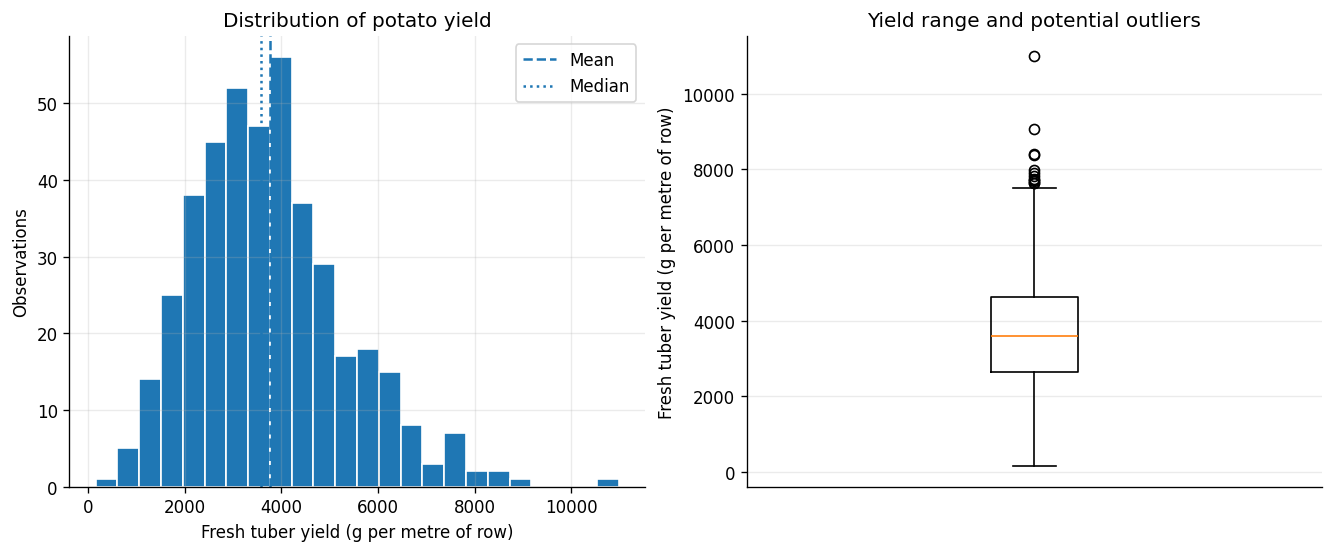

In [3]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(data[target_column], bins=24, edgecolor="white")
axes[0].axvline(data[target_column].mean(), linestyle="--", label="Mean")
axes[0].axvline(data[target_column].median(), linestyle=":", label="Median")
axes[0].set(
    title="Distribution of potato yield",
    xlabel="Fresh tuber yield (g per metre of row)",
    ylabel="Observations",
)
axes[0].legend()

axes[1].boxplot(data[target_column], vert=True)
axes[1].set(
    title="Yield range and potential outliers",
    ylabel="Fresh tuber yield (g per metre of row)",
    xticks=[],
)

save_figure(figure, "yield-distribution")
figure

### Missingness and conventional predictors

Missing-data patterns and relationships among conventional soil-chemistry variables are reviewed descriptively. Correlations are not used here to select predictors.

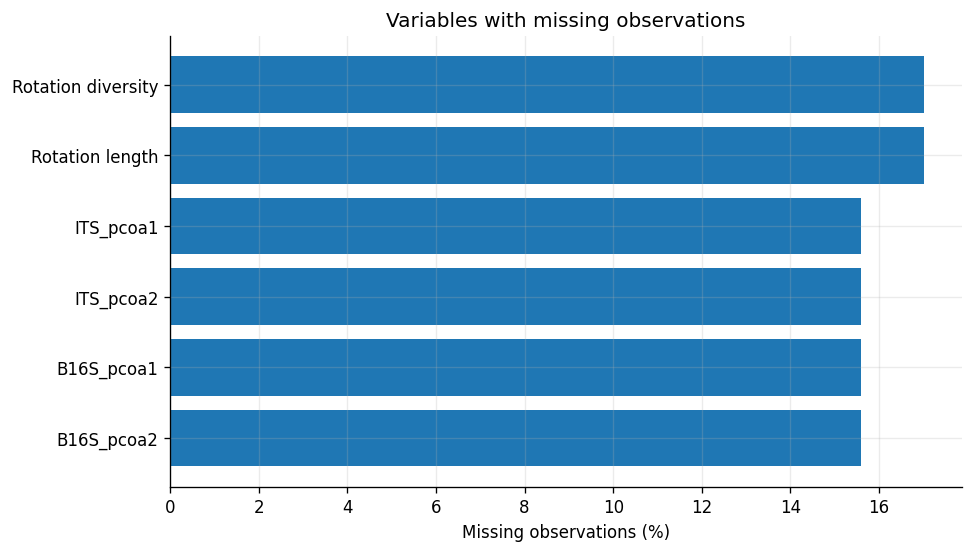

,variable,missing-count,missing-percent
0,Rotation length,72,17.0213
1,Rotation diversity,72,17.0213
2,B16S_pcoa1,66,15.6028
3,B16S_pcoa2,66,15.6028
4,ITS_pcoa1,66,15.6028
5,ITS_pcoa2,66,15.6028


In [4]:
if missingness_summary.empty:
    print("No missing values were found in the analytical table.")
else:
    figure, axis = plt.subplots(figsize=(8, 4.5))
    plot_table = missingness_summary.sort_values("missing-percent")
    axis.barh(plot_table["variable"], plot_table["missing-percent"])
    axis.set(
        title="Variables with missing observations",
        xlabel="Missing observations (%)",
        ylabel="",
    )
    save_figure(figure, "missingness-profile")
    display(figure)

missingness_summary

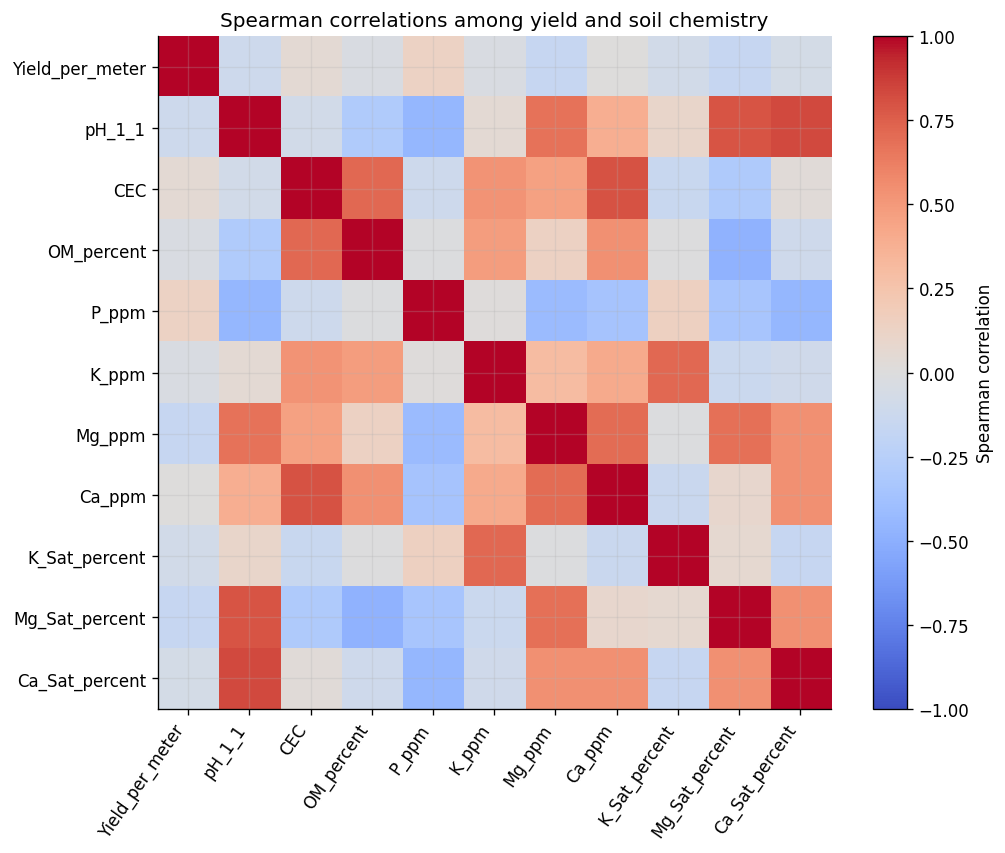

In [5]:
soil_columns = feature_blocks["soil-chemistry"]
soil_correlation = data[[target_column, *soil_columns]].corr(method="spearman")
save_table(soil_correlation.reset_index(names="variable"), "soil-correlation")

figure, axis = plt.subplots(figsize=(8.5, 7))
image = axis.imshow(soil_correlation, vmin=-1, vmax=1, cmap="coolwarm")
_axis_labels = soil_correlation.columns.tolist()
axis.set_xticks(range(len(_axis_labels)), _axis_labels, rotation=55, ha="right")
axis.set_yticks(range(len(_axis_labels)), _axis_labels)
axis.set_title("Spearman correlations among yield and soil chemistry")
figure.colorbar(image, ax=axis, label="Spearman correlation")

save_figure(figure, "soil-correlation")
figure

### Microbial summaries

qPCR abundance variables and Shannon diversity indices are compact summaries of microbial abundance and diversity. Their scales and distributions are inspected separately from the taxonomic matrices.

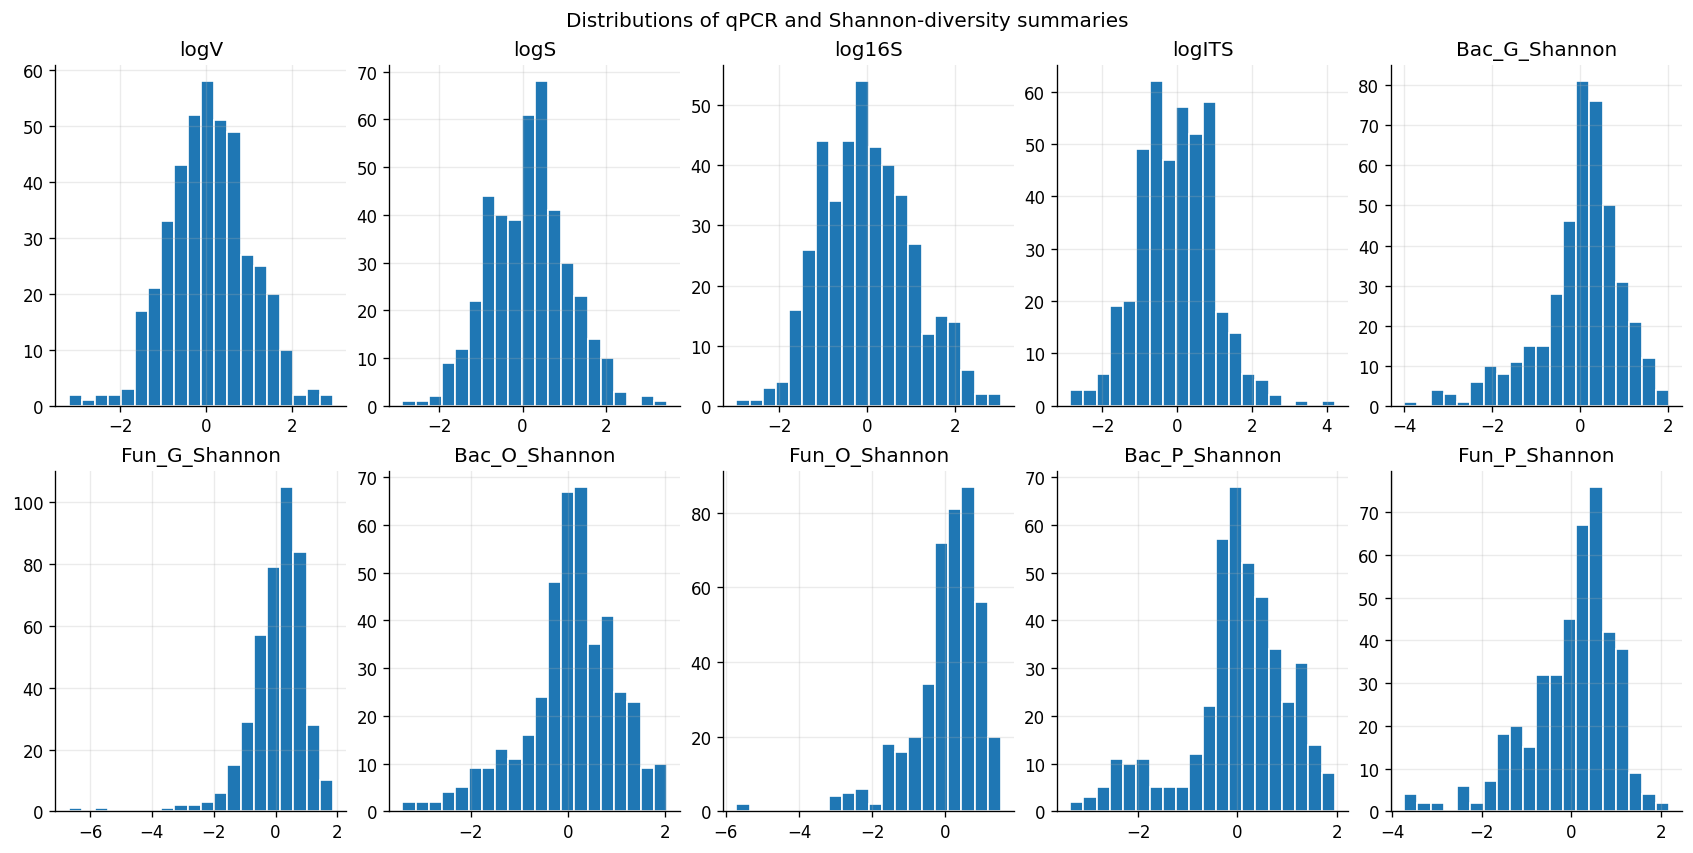

In [6]:
microbial_summary_columns = [
    *feature_blocks["qpcr"],
    *feature_blocks["shannon"],
]

microbial_summary = (
    data[microbial_summary_columns]
    .describe()
    .T
    .reset_index(names="variable")
)
save_table(microbial_summary, "microbial-summary")

figure, axes = plt.subplots(2, 5, figsize=(14, 7))
for axis, column in zip(axes.flat, microbial_summary_columns):
    axis.hist(data[column].dropna(), bins=20, edgecolor="white")
    axis.set_title(column)
    axis.set_xlabel("")
    axis.set_ylabel("")

figure.suptitle("Distributions of qPCR and Shannon-diversity summaries")
save_figure(figure, "microbial-summaries")
figure

### Taxonomic sparsity and prevalence

The bacterial and fungal relative-abundance matrices contain many zeros. Prevalence is inspected to quantify how often each taxon is observed, without yet choosing a modelling threshold.

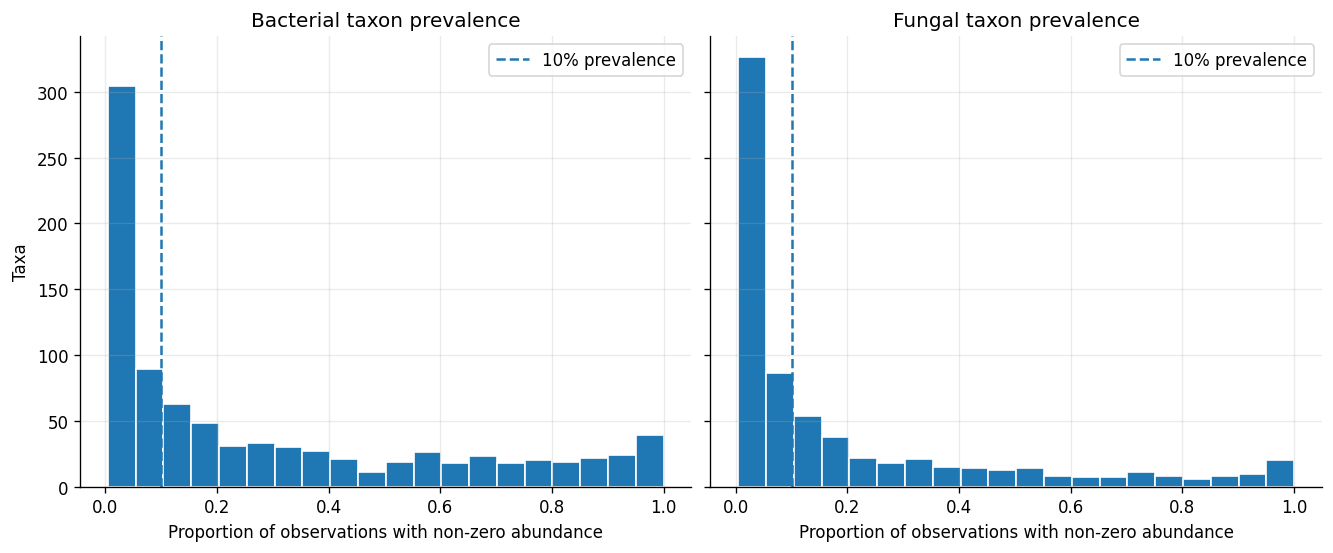

In [7]:
bacterial_prevalence = data[feature_blocks["bacterial-taxa"]].gt(0).mean(axis=0)
fungal_prevalence = data[feature_blocks["fungal-taxa"]].gt(0).mean(axis=0)

taxa_prevalence = pd.concat(
    [
        bacterial_prevalence.rename("prevalence").to_frame().assign(block="bacterial"),
        fungal_prevalence.rename("prevalence").to_frame().assign(block="fungal"),
    ]
).reset_index(names="variable")
save_table(taxa_prevalence, "taxa-prevalence")

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
axes[0].hist(bacterial_prevalence, bins=20, edgecolor="white")
axes[0].axvline(0.10, linestyle="--", label="10% prevalence")
axes[0].set(
    title="Bacterial taxon prevalence",
    xlabel="Proportion of observations with non-zero abundance",
    ylabel="Taxa",
)
axes[0].legend()

axes[1].hist(fungal_prevalence, bins=20, edgecolor="white")
axes[1].axvline(0.10, linestyle="--", label="10% prevalence")
axes[1].set(
    title="Fungal taxon prevalence",
    xlabel="Proportion of observations with non-zero abundance",
)
axes[1].legend()

save_figure(figure, "taxa-prevalence")
figure

### Exploratory community ordination

The dataset includes two bacterial and two fungal PCoA axes derived from community composition. These axes are used only to visualise low-dimensional structure and possible broad yield gradients.

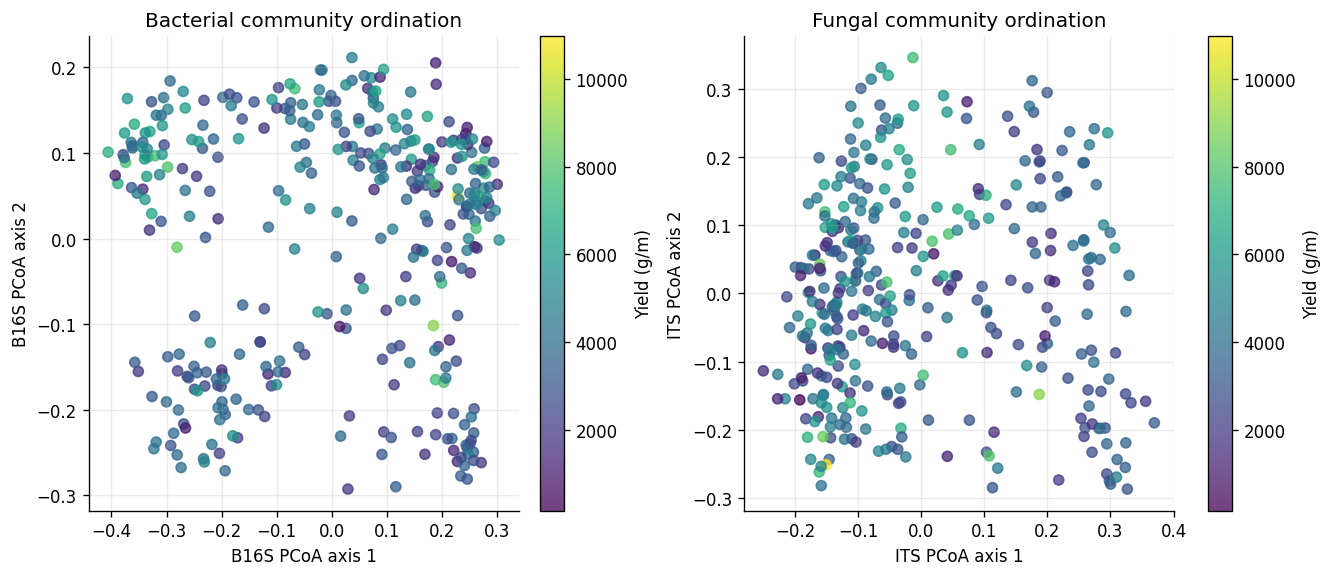

In [8]:
pcoa_columns = feature_blocks["pcoa"]

figure, axes = plt.subplots(1, 2, figsize=(11, 4.7))

bacterial_scatter = axes[0].scatter(
    data["B16S_pcoa1"],
    data["B16S_pcoa2"],
    c=data[target_column],
    alpha=0.75,
)
axes[0].set(
    title="Bacterial community ordination",
    xlabel="B16S PCoA axis 1",
    ylabel="B16S PCoA axis 2",
)
figure.colorbar(bacterial_scatter, ax=axes[0], label="Yield (g/m)")

fungal_scatter = axes[1].scatter(
    data["ITS_pcoa1"],
    data["ITS_pcoa2"],
    c=data[target_column],
    alpha=0.75,
)
axes[1].set(
    title="Fungal community ordination",
    xlabel="ITS PCoA axis 1",
    ylabel="ITS PCoA axis 2",
)
figure.colorbar(fungal_scatter, ax=axes[1], label="Yield (g/m)")

save_figure(figure, "community-ordination")
figure

### Exploratory findings

The exploratory analysis highlights several characteristics that will shape the modelling workflow:

- `Yield_per_meter` is continuous and right-skewed, with a small number of high-yield observations. A transformed-target sensitivity analysis may therefore be useful later, while final error metrics should remain interpretable on the original gram-per-metre scale.
- Missingness is concentrated in the crop-rotation variables rather than distributed throughout the dataset. Their imputation strategy will be handled explicitly in the feature-engineering pipeline.
- qPCR variables and Shannon diversity measures are compact microbial summaries, whereas the bacterial and fungal abundance matrices are high-dimensional and sparse.
- Taxon prevalence varies widely. Filtering rare and near-constant features before supervised selection is likely to be necessary, but all modelling filters must be learned from training data only.
- The supplied bacterial and fungal PCoA axes provide an exploratory view of community structure. They are not evidence of a linear yield gradient and will not automatically be combined with the full taxonomic matrices, because they summarise the same underlying sequencing information.

These findings are descriptive. They do not establish that any soil or microbial variable causes higher or lower yield.

## Feature Engineering

This section translates the raw variables into modelling-ready representations while preserving their scientific meaning. The transformations are deliberately simple and will be fitted inside each resampling split during model development.

The qPCR variables are already supplied on a logarithmic scale, as indicated by their names (`logV`, `logS`, `log16S`, and `logITS`), so they are not log-transformed again. Taxonomic relative abundances are handled separately for bacteria and fungi using prevalence filtering followed by a centred log-ratio (CLR) transformation with a training-derived pseudocount.

### Predictor roles and modelling sets

Identifiers and the response are excluded from the predictor matrix. The modelling sets are organised incrementally so that later comparisons can distinguish the value of conventional agronomic information, compact microbial summaries, community ordination, and high-dimensional taxonomic composition.

PCoA axes are not combined with the full taxonomic matrices in the integrated set because they are derived from the same community data and would introduce avoidable redundancy.

In [9]:
# Define predictor roles used by the feature-engineering pipelines.
management_columns = feature_blocks["management"]
soil_columns = feature_blocks["soil-chemistry"]
qpcr_columns = feature_blocks["qpcr"]
shannon_columns = feature_blocks["shannon"]
pcoa_columns = feature_blocks["pcoa"]
bacterial_taxa_columns = feature_blocks["bacterial-taxa"]
fungal_taxa_columns = feature_blocks["fungal-taxa"]

categorical_columns = [
    column
    for column in management_columns
    if not pd.api.types.is_numeric_dtype(data[column])
]
numeric_management_columns = [
    column for column in management_columns if column not in categorical_columns
]
conventional_numeric_columns = [*numeric_management_columns, *soil_columns]
summary_numeric_columns = [*qpcr_columns, *shannon_columns]

modelling_feature_sets = {
    "conventional": {
        "categorical": categorical_columns,
        "numeric": conventional_numeric_columns,
        "bacterial-taxa": [],
        "fungal-taxa": [],
    },
    "conventional-plus-summaries": {
        "categorical": categorical_columns,
        "numeric": [*conventional_numeric_columns, *summary_numeric_columns],
        "bacterial-taxa": [],
        "fungal-taxa": [],
    },
    "conventional-plus-pcoa": {
        "categorical": categorical_columns,
        "numeric": [
            *conventional_numeric_columns,
            *summary_numeric_columns,
            *pcoa_columns,
        ],
        "bacterial-taxa": [],
        "fungal-taxa": [],
    },
    "conventional-plus-taxa": {
        "categorical": categorical_columns,
        "numeric": conventional_numeric_columns,
        "bacterial-taxa": bacterial_taxa_columns,
        "fungal-taxa": fungal_taxa_columns,
    },
    "integrated": {
        "categorical": categorical_columns,
        "numeric": [*conventional_numeric_columns, *summary_numeric_columns],
        "bacterial-taxa": bacterial_taxa_columns,
        "fungal-taxa": fungal_taxa_columns,
    },
}

feature_set_summary = pd.DataFrame(
    [
        {
            "feature-set": feature_set,
            "categorical-features": len(specification["categorical"]),
            "numeric-features": len(specification["numeric"]),
            "bacterial-taxa": len(specification["bacterial-taxa"]),
            "fungal-taxa": len(specification["fungal-taxa"]),
            "raw-feature-count": sum(len(columns) for columns in specification.values()),
        }
        for feature_set, specification in modelling_feature_sets.items()
    ]
)

save_table(feature_set_summary, "feature-set-summary")
feature_set_summary

,feature-set,categorical-features,numeric-features,bacterial-taxa,fungal-taxa,raw-feature-count
0,conventional,8,12,0,0,20
1,conventional-plus-summaries,8,22,0,0,30
2,conventional-plus-pcoa,8,26,0,0,34
3,conventional-plus-taxa,8,12,885,706,1611
4,integrated,8,22,885,706,1621


### Fold-safe transformations

Numeric predictors are median-imputed and standardised. Categorical predictors are mode-imputed and one-hot encoded, with unseen categories ignored at prediction time. Missingness indicators are retained for numeric variables because an absent rotation-history value may itself distinguish records with incomplete management information.

For each taxonomic block, taxa below the minimum prevalence threshold are removed using only the training data. Remaining zeros are replaced by a small pseudocount inferred from the smallest positive training abundance, after which the CLR transformation maps each sample to log-ratios relative to its geometric mean. This approach respects the relative nature of the community measurements while remaining transparent and compatible with scikit-learn pipelines.

In [10]:
class PrevalenceCLRTransformer(BaseEstimator, TransformerMixin):
    """
    Description:
    ------------
    Filter sparse compositional features by prevalence and apply a CLR transformation.

    Input:
    ------
    minimum_prevalence : float
        Minimum positive-value prevalence required in the training data.
    pseudocount_fraction : float
        Fraction of the smallest positive training abundance used as pseudocount.

    Outputs:
    --------
    transformer : PrevalenceCLRTransformer
        Fitted transformer that returns CLR-transformed retained features.

    Author:
    -------
    Rodrigo Kang
    """

    def __init__(self, minimum_prevalence=0.05, pseudocount_fraction=0.5):
        self.minimum_prevalence = minimum_prevalence
        self.pseudocount_fraction = pseudocount_fraction

    def fit(self, x, y=None):
        """
        Description:
        ------------
        Learn the prevalence mask and pseudocount from training observations.

        Input:
        ------
        x : array-like
            Non-negative relative-abundance matrix.
        y : array-like or None
            Optional response, unused by this transformer.

        Outputs:
        --------
        self : PrevalenceCLRTransformer
            Fitted transformer.

        Author:
        -------
        Rodrigo Kang
        """
        x_array = self._validate_input(x)
        prevalence = np.mean(x_array > 0, axis=0)
        self.feature_mask_ = prevalence >= self.minimum_prevalence

        if not np.any(self.feature_mask_):
            raise ValueError(
                "No taxonomic features satisfy the minimum prevalence threshold."
            )

        retained = x_array[:, self.feature_mask_]
        positive_values = retained[retained > 0]
        if positive_values.size == 0:
            raise ValueError("The retained taxonomic block has no positive values.")

        self.pseudocount_ = float(
            positive_values.min() * self.pseudocount_fraction
        )
        self.n_features_in_ = x_array.shape[1]
        if hasattr(x, "columns"):
            self.feature_names_in_ = np.asarray(x.columns, dtype=object)
        return self

    def transform(self, x):
        """
        Description:
        ------------
        Apply the learned prevalence filter, zero replacement, and CLR transform.

        Input:
        ------
        x : array-like
            Relative-abundance matrix with the training feature structure.

        Outputs:
        --------
        transformed : numpy.ndarray
            CLR-transformed retained taxonomic features.

        Author:
        -------
        Rodrigo Kang
        """
        x_array = self._validate_input(x)
        if x_array.shape[1] != self.n_features_in_:
            raise ValueError("Taxonomic feature count differs from the fitted data.")

        retained = x_array[:, self.feature_mask_]
        replaced = np.where(retained > 0, retained, self.pseudocount_)
        log_values = np.log(replaced)
        return log_values - log_values.mean(axis=1, keepdims=True)

    def get_feature_names_out(self, input_features=None):
        """
        Description:
        ------------
        Return the names of taxonomic features retained during fitting.

        Input:
        ------
        input_features : array-like or None
            Original feature names supplied by scikit-learn.

        Outputs:
        --------
        feature_names : numpy.ndarray
            Names of retained features.

        Author:
        -------
        Rodrigo Kang
        """
        if input_features is None:
            input_features = getattr(
                self,
                "feature_names_in_",
                np.asarray([f"x{index}" for index in range(self.n_features_in_)]),
            )
        return np.asarray(input_features, dtype=object)[self.feature_mask_]

    @staticmethod
    def _validate_input(x):
        """
        Description:
        ------------
        Convert a taxonomic matrix to a finite non-negative NumPy array.

        Input:
        ------
        x : array-like
            Candidate taxonomic abundance matrix.

        Outputs:
        --------
        x_array : numpy.ndarray
            Validated floating-point matrix.

        Author:
        -------
        Rodrigo Kang
        """
        x_array = np.asarray(x, dtype=float)
        if x_array.ndim != 2:
            raise ValueError("Taxonomic input must be a two-dimensional matrix.")
        if not np.isfinite(x_array).all():
            raise ValueError("Taxonomic input contains missing or infinite values.")
        if (x_array < 0).any():
            raise ValueError("Taxonomic relative abundances cannot be negative.")
        return x_array


def build_feature_engineer(feature_set, scale_numeric=True):
    """
    Description:
    ------------
    Build a fold-safe feature-engineering transformer for one modelling set.

    Input:
    ------
    feature_set : str
        Key identifying a modelling feature set.
    scale_numeric : bool
        Whether to standardise imputed numeric predictors.

    Outputs:
    --------
    feature_engineer : sklearn.compose.ColumnTransformer
        Configured feature-engineering transformer.

    Author:
    -------
    Rodrigo Kang
    """
    if feature_set not in modelling_feature_sets:
        raise KeyError(f"Unknown feature set: {feature_set!r}.")

    specification = modelling_feature_sets[feature_set]
    transformers = []

    if specification["numeric"]:
        numeric_steps = [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ]
        if scale_numeric:
            numeric_steps.append(("scaler", StandardScaler()))
        transformers.append(
            (
                "numeric",
                Pipeline(numeric_steps),
                specification["numeric"],
            )
        )

    if specification["categorical"]:
        categorical_pipeline = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                ),
            ]
        )
        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                specification["categorical"],
            )
        )

    for block_name in ("bacterial-taxa", "fungal-taxa"):
        if specification[block_name]:
            transformers.append(
                (
                    block_name,
                    PrevalenceCLRTransformer(minimum_prevalence=0.05),
                    specification[block_name],
                )
            )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=True,
    )


### Structural validation

A temporary train/test partition is used only to verify that every feature-engineering configuration can be fitted on one subset and applied to unseen rows with an identical output structure. This is not a reported performance evaluation and does not replace the cross-validation strategy defined later.

In [11]:
# Validate feature-engineering structures without evaluating predictive performance.
all_predictor_columns = sorted(
    {
        column
        for specification in modelling_feature_sets.values()
        for columns in specification.values()
        for column in columns
    }
)

engineering_train, engineering_test = train_test_split(
    data,
    test_size=0.20,
    random_state=random_seed,
)

feature_engineering_checks = []
for feature_set in modelling_feature_sets:
    transformer = build_feature_engineer(feature_set, scale_numeric=True)
    train_matrix = transformer.fit_transform(engineering_train)
    test_matrix = transformer.transform(engineering_test)
    feature_names = transformer.get_feature_names_out()

    if train_matrix.shape[1] != test_matrix.shape[1]:
        raise RuntimeError(
            f"Feature count changed between training and test data for {feature_set}."
        )
    if train_matrix.shape[1] != len(feature_names):
        raise RuntimeError(
            f"Feature names do not match the transformed matrix for {feature_set}."
        )
    if not np.isfinite(train_matrix).all() or not np.isfinite(test_matrix).all():
        raise RuntimeError(
            f"Non-finite transformed values were produced for {feature_set}."
        )

    feature_engineering_checks.append(
        {
            "feature-set": feature_set,
            "raw-features": feature_set_summary.loc[
                feature_set_summary["feature-set"].eq(feature_set),
                "raw-feature-count",
            ].iloc[0],
            "engineered-features": train_matrix.shape[1],
            "train-observations": train_matrix.shape[0],
            "test-observations": test_matrix.shape[0],
            "finite-output": True,
        }
    )

feature_engineering_check = pd.DataFrame(feature_engineering_checks)

feature_engineering_plan = pd.DataFrame(
    [
        {
            "variable-block": "numeric conventional and microbial summaries",
            "transformation": "median imputation with missingness indicators; optional standardisation",
            "fitted-inside-resampling": True,
        },
        {
            "variable-block": "categorical management",
            "transformation": "mode imputation and one-hot encoding",
            "fitted-inside-resampling": True,
        },
        {
            "variable-block": "qPCR abundance",
            "transformation": "retain supplied logarithmic scale; median imputation and standardisation",
            "fitted-inside-resampling": True,
        },
        {
            "variable-block": "bacterial relative abundance",
            "transformation": "5% prevalence filter and CLR using a training-derived pseudocount",
            "fitted-inside-resampling": True,
        },
        {
            "variable-block": "fungal relative abundance",
            "transformation": "5% prevalence filter and CLR using a training-derived pseudocount",
            "fitted-inside-resampling": True,
        },
    ]
)

save_table(feature_engineering_check, "feature-engineering-check")
save_table(feature_engineering_plan, "feature-engineering-plan")

feature_engineering_check

,feature-set,raw-features,engineered-features,train-observations,test-observations,finite-output
0,conventional,20,43,338,85,True
1,conventional-plus-summaries,30,53,338,85,True
2,conventional-plus-pcoa,34,61,338,85,True
3,conventional-plus-taxa,1611,1035,338,85,True
4,integrated,1621,1045,338,85,True


## Feature Selection

This section reduces redundant and weakly informative predictors before model fitting. A variance filter removes columns that carry no usable variation after feature engineering, while a supervised univariate filter ranks the remaining predictors by their training-only association with `Yield_per_meter`. Both steps will be fitted inside each resampling split during model selection.

PCA is not used as the primary feature-selection method because its components maximise predictor variance rather than predictive relevance and make biological interpretation less direct. The existing community ordination remains useful as an exploratory representation.

In [12]:
class AdaptiveSelectKBest(BaseEstimator, TransformerMixin):
    """
    Description:
    ------------
    Select up to k predictors using a univariate supervised scoring function.

    Input:
    ------
    score_func : callable
        Scoring function compatible with scikit-learn feature selection.
    k : int or str
        Maximum number of predictors to retain, or "all".

    Outputs:
    --------
    selector : AdaptiveSelectKBest
        Fitted selector that safely caps k at the available feature count.

    Author:
    -------
    Rodrigo Kang
    """

    def __init__(self, score_func=f_regression, k=100):
        self.score_func = score_func
        self.k = k

    def fit(self, x, y):
        """
        Description:
        ------------
        Fit the supervised selector using the supplied training observations.

        Input:
        ------
        x : array-like
            Engineered predictor matrix.
        y : array-like
            Continuous training response.

        Outputs:
        --------
        self : AdaptiveSelectKBest
            Fitted selector.

        Author:
        -------
        Rodrigo Kang
        """
        x_array = np.asarray(x, dtype=float)
        if x_array.ndim != 2:
            raise ValueError("Feature-selection input must be two-dimensional.")
        if not np.isfinite(x_array).all():
            raise ValueError("Feature-selection input contains non-finite values.")

        if self.k == "all":
            effective_k = "all"
        else:
            if not isinstance(self.k, (int, np.integer)) or self.k < 1:
                raise ValueError("k must be a positive integer or 'all'.")
            effective_k = min(int(self.k), x_array.shape[1])

        self.selector_ = SelectKBest(score_func=self.score_func, k=effective_k)
        self.selector_.fit(x_array, y)
        self.effective_k_ = effective_k
        self.n_features_in_ = x_array.shape[1]
        return self

    def transform(self, x):
        """
        Description:
        ------------
        Retain the predictors selected from the training data.

        Input:
        ------
        x : array-like
            Engineered predictor matrix with the fitted feature structure.

        Outputs:
        --------
        transformed : numpy.ndarray
            Matrix containing the selected predictors.

        Author:
        -------
        Rodrigo Kang
        """
        return self.selector_.transform(x)

    def get_support(self, indices=False):
        """
        Description:
        ------------
        Return the mask or indices of selected predictors.

        Input:
        ------
        indices : bool
            Whether to return integer indices instead of a Boolean mask.

        Outputs:
        --------
        support : numpy.ndarray
            Selected-feature mask or indices.

        Author:
        -------
        Rodrigo Kang
        """
        return self.selector_.get_support(indices=indices)

    def get_feature_names_out(self, input_features=None):
        """
        Description:
        ------------
        Return names corresponding to the selected predictors.

        Input:
        ------
        input_features : array-like or None
            Names of the engineered input predictors.

        Outputs:
        --------
        feature_names : numpy.ndarray
            Names of retained predictors.

        Author:
        -------
        Rodrigo Kang
        """
        if input_features is None:
            input_features = np.asarray(
                [f"x{index}" for index in range(self.n_features_in_)],
                dtype=object,
            )
        return np.asarray(input_features, dtype=object)[self.get_support()]


def build_feature_selector(k=100, variance_threshold=0.0):
    """
    Description:
    ------------
    Build an unsupervised variance filter followed by supervised selection.

    Input:
    ------
    k : int or str
        Maximum number of predictors retained by the supervised selector.
    variance_threshold : float
        Minimum variance required after feature engineering.

    Outputs:
    --------
    feature_selector : sklearn.pipeline.Pipeline
        Configured feature-selection pipeline.

    Author:
    -------
    Rodrigo Kang
    """
    return Pipeline(
        [
            ("variance", VarianceThreshold(threshold=variance_threshold)),
            ("supervised", AdaptiveSelectKBest(score_func=f_regression, k=k)),
        ]
    )


def build_selection_pipeline(feature_set, k=100, scale_numeric=True):
    """
    Description:
    ------------
    Combine fold-safe feature engineering and feature selection.

    Input:
    ------
    feature_set : str
        Key identifying a modelling feature set.
    k : int or str
        Maximum number of predictors retained after engineering.
    scale_numeric : bool
        Whether to standardise numeric predictors.

    Outputs:
    --------
    selection_pipeline : sklearn.pipeline.Pipeline
        Feature-engineering and feature-selection pipeline.

    Author:
    -------
    Rodrigo Kang
    """
    return Pipeline(
        [
            (
                "feature_engineering",
                build_feature_engineer(
                    feature_set=feature_set,
                    scale_numeric=scale_numeric,
                ),
            ),
            ("feature_selection", build_feature_selector(k=k)),
        ]
    )


selection_candidates = [25, 50, 100, 250, 500, "all"]
feature_selection_plan = pd.DataFrame(
    [
        {
            "step": "variance-filter",
            "method": "VarianceThreshold",
            "purpose": "remove engineered predictors with no training variation",
            "uses-target": False,
            "fitted-inside-resampling": True,
        },
        {
            "step": "supervised-ranking",
            "method": "SelectKBest with f-regression",
            "purpose": "retain predictors with the strongest training-only univariate associations",
            "uses-target": True,
            "fitted-inside-resampling": True,
        },
        {
            "step": "exploratory-reduction",
            "method": "PCA and supplied PCoA axes",
            "purpose": "visualise broad community structure rather than select final predictors",
            "uses-target": False,
            "fitted-inside-resampling": False,
        },
    ]
)

# Structural check on a temporary partition; this is not a performance estimate.
selection_checks = []
selection_examples = []
selection_x_train = engineering_train.drop(columns=[target_column])
selection_x_test = engineering_test.drop(columns=[target_column])
selection_y_train = engineering_train[target_column]

for feature_set in modelling_feature_sets:
    engineered_count = feature_engineering_check.loc[
        feature_engineering_check["feature-set"].eq(feature_set),
        "engineered-features",
    ].iloc[0]
    illustrative_k = min(100, int(engineered_count))
    pipeline = build_selection_pipeline(
        feature_set=feature_set,
        k=illustrative_k,
        scale_numeric=True,
    )
    selected_train = pipeline.fit_transform(selection_x_train, selection_y_train)
    selected_test = pipeline.transform(selection_x_test)

    feature_engineer = pipeline.named_steps["feature_engineering"]
    selector = pipeline.named_steps["feature_selection"]
    engineered_names = feature_engineer.get_feature_names_out()
    variance_mask = selector.named_steps["variance"].get_support()
    variable_names = engineered_names[variance_mask]
    selected_names = selector.named_steps["supervised"].get_feature_names_out(
        variable_names
    )

    if selected_train.shape[1] != selected_test.shape[1]:
        raise RuntimeError(
            f"Selected feature count changed between partitions for {feature_set}."
        )
    if selected_train.shape[1] != len(selected_names):
        raise RuntimeError(
            f"Selected feature names do not match the matrix for {feature_set}."
        )
    if not np.isfinite(selected_train).all() or not np.isfinite(selected_test).all():
        raise RuntimeError(
            f"Feature selection produced non-finite values for {feature_set}."
        )

    selection_checks.append(
        {
            "feature-set": feature_set,
            "engineered-features": len(engineered_names),
            "after-variance-filter": int(variance_mask.sum()),
            "requested-k": illustrative_k,
            "selected-features": selected_train.shape[1],
            "finite-output": True,
        }
    )

    selector_scores = selector.named_steps["supervised"].selector_.scores_
    score_table = pd.DataFrame(
        {
            "feature-set": feature_set,
            "feature": variable_names,
            "training-f-score": selector_scores,
            "selected": selector.named_steps["supervised"].get_support(),
        }
    )
    selection_examples.append(
        score_table.sort_values("training-f-score", ascending=False).head(20)
    )

feature_selection_check = pd.DataFrame(selection_checks)
illustrative_feature_scores = pd.concat(selection_examples, ignore_index=True)

save_table(feature_selection_plan, "feature-selection-plan")
save_table(feature_selection_check, "feature-selection-check")
save_table(illustrative_feature_scores, "illustrative-feature-scores")

feature_selection_check

,feature-set,engineered-features,after-variance-filter,requested-k,selected-features,finite-output
0,conventional,43,43,43,43,True
1,conventional-plus-summaries,53,53,53,53,True
2,conventional-plus-pcoa,61,61,61,61,True
3,conventional-plus-taxa,1035,1035,100,100,True
4,integrated,1045,1045,100,100,True


### Selection strategy for model comparison

The number of retained predictors will be treated as a model-selection parameter rather than fixed from the full dataset. Small candidate sets favour parsimonious models, while larger candidates allow the benchmark to test whether broader microbial signatures add predictive value. The candidate value is capped automatically when a feature set contains fewer engineered predictors.

The exported `illustrative-feature-scores.csv` is a structural diagnostic from the temporary development partition only. It is not used to claim that those variables are definitively important; final feature rankings must be derived from resampled training data or out-of-sample permutation importance.

In [13]:
feature_selection_candidates = pd.DataFrame(
    {
        "candidate-k": [str(value) for value in selection_candidates],
        "interpretation": [
            "very compact predictor set",
            "compact predictor set",
            "moderate predictor set",
            "broader high-dimensional set",
            "large high-dimensional set",
            "retain every non-constant engineered predictor",
        ],
    }
)

save_table(feature_selection_candidates, "feature-selection-candidates")
feature_selection_candidates

,candidate-k,interpretation
0,25,very compact predictor set
1,50,compact predictor set
2,100,moderate predictor set
3,250,broader high-dimensional set
4,500,large high-dimensional set
5,all,retain every non-constant engineered predictor


## Model Benchmark

This section will compare a compact set of methodologically distinct regression models, including linear regularised models and tree-based ensembles, against a naive baseline.

The benchmark is conducted only on an 80% development partition. The remaining 20% is reserved as an untouched holdout set and is not used to compare feature sets, select models, or tune hyperparameters. Within the development data, a fixed five-fold shuffled `KFold` split provides the primary model-screening framework. Every candidate is evaluated through a complete pipeline, so imputation, encoding, compositional transformation, variance filtering, and supervised feature selection are re-estimated inside every training fold.

In [ ]:
def build_benchmark_estimator(model_name):
    """
    Description:
    ------------
    Build one regression estimator with a sensible untuned configuration.

    Input:
    ------
    model_name : str
        Key identifying the benchmark model.

    Outputs:
    --------
    estimator : sklearn estimator
        Configured regression estimator.

    Author:
    -------
    Rodrigo Kang
    """
    estimators = {
        "naive-mean": DummyRegressor(strategy="mean"),
        "linear-regression": LinearRegression(),
        "ridge": Ridge(alpha=10.0),
        "lasso": Lasso(alpha=1.0, max_iter=20_000, random_state=random_seed),
        "elastic-net": ElasticNet(
            alpha=1.0,
            l1_ratio=0.5,
            max_iter=20_000,
            random_state=random_seed,
        ),
        "random-forest": RandomForestRegressor(
            n_estimators=250,
            max_features="sqrt",
            min_samples_leaf=3,
            n_jobs=-1,
            random_state=random_seed,
        ),
        "hist-gradient-boosting": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=250,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=random_seed,
        ),
    }

    if model_name not in estimators:
        raise KeyError(f"Unknown benchmark model: {model_name!r}.")

    return clone(estimators[model_name])


def build_benchmark_pipeline(feature_set, model_name, selected_features):
    """
    Description:
    ------------
    Combine fold-safe feature preparation, selection, and regression.

    Input:
    ------
    feature_set : str
        Key identifying the modelling information block.
    model_name : str
        Key identifying the benchmark estimator.
    selected_features : int or str
        Maximum number of predictors retained inside each fold.

    Outputs:
    --------
    pipeline : sklearn.pipeline.Pipeline
        Complete benchmark pipeline.

    Author:
    -------
    Rodrigo Kang
    """
    if model_name == "naive-mean":
        return Pipeline([("model", build_benchmark_estimator(model_name))])

    scale_numeric = model_name in {
        "linear-regression",
        "ridge",
        "lasso",
        "elastic-net",
    }

    return Pipeline(
        [
            (
                "feature_preparation",
                build_selection_pipeline(
                    feature_set=feature_set,
                    k=selected_features,
                    scale_numeric=scale_numeric,
                ),
            ),
            ("model", build_benchmark_estimator(model_name)),
        ]
    )


def evaluate_benchmark_candidate(
    x,
    y,
    feature_set,
    model_name,
    selected_features,
    cv_splits,
):
    """
    Description:
    ------------
    Evaluate one pipeline with conventional cross-validation.

    Input:
    ------
    x : pandas.DataFrame
        Predictor table.
    y : pandas.Series
        Continuous response.
    feature_set : str
        Key identifying the modelling information block.
    model_name : str
        Key identifying the benchmark estimator.
    selected_features : int or str
        Maximum number of predictors retained inside each fold.
    cv_splits : list
        Precomputed train and validation index pairs.

    Outputs:
    --------
    fold_metrics : pandas.DataFrame
        Fold-level MAE, RMSE, and R-squared values.

    Author:
    -------
    Rodrigo Kang
    """
    pipeline = build_benchmark_pipeline(
        feature_set=feature_set,
        model_name=model_name,
        selected_features=selected_features,
    )
    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    }
    scores = cross_validate(
        pipeline,
        x,
        y,
        cv=cv_splits,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )

    return pd.DataFrame(
        {
            "feature-set": feature_set,
            "model": model_name,
            "selected-features": str(selected_features),
            "fold": np.arange(1, len(cv_splits) + 1),
            "mae": -scores["test_mae"],
            "rmse": -scores["test_rmse"],
            "r2": scores["test_r2"],
            "fit-seconds": scores["fit_time"],
            "score-seconds": scores["score_time"],
        }
    )



# Reserve an untouched holdout set before model screening.
yield_bins = pd.qcut(
    data[target_column],
    q=5,
    labels=False,
    duplicates="drop",
)
development_indices, holdout_indices = train_test_split(
    np.arange(len(data)),
    test_size=0.20,
    random_state=random_seed,
    stratify=yield_bins,
)

development_data = data.iloc[development_indices].copy()
holdout_data = data.iloc[holdout_indices].copy()

split_assignment = pd.DataFrame(
    {
        "row-index": np.arange(len(data)),
        "sample": data["Sample"].astype(str).to_numpy(),
        "partition": np.where(
            np.isin(np.arange(len(data)), development_indices),
            "development",
            "holdout",
        ),
    }
)
save_table(split_assignment, "data-split")

benchmark_models = [
    "naive-mean",
    "linear-regression",
    "ridge",
    "lasso",
    "elastic-net",
    "random-forest",
    "hist-gradient-boosting",
]

benchmark_selected_features = {
    "conventional": "all",
    "conventional-plus-summaries": "all",
    "conventional-plus-pcoa": "all",
    "conventional-plus-taxa": 250,
    "integrated": 250,
}

benchmark_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_seed,
)
benchmark_splits = list(benchmark_cv.split(development_data))

benchmark_plan = pd.DataFrame(
    [
        {
            "feature-set": feature_set,
            "model": model_name,
            "selected-features": str(benchmark_selected_features[feature_set]),
            "primary-resampling": "5-fold shuffled KFold",
        }
        for feature_set in modelling_feature_sets
        for model_name in benchmark_models
    ]
)

save_table(benchmark_plan, "benchmark-plan")
benchmark_plan


The complete benchmark can take several minutes because taxonomic transformations and supervised selection are refitted repeatedly. Results are saved after each candidate so that an interrupted local run can resume without repeating completed combinations.

In [ ]:
benchmark_checkpoint_dir = tables_dir / "benchmark-checkpoints-v2"
benchmark_checkpoint_dir.mkdir(parents=True, exist_ok=True)

benchmark_x = development_data.drop(columns=[target_column])
benchmark_y = development_data[target_column]

for feature_set in modelling_feature_sets:
    for model_name in benchmark_models:
        checkpoint_name = f"{feature_set}-{model_name}"
        checkpoint_path = benchmark_checkpoint_dir / f"{checkpoint_name}.csv"

        if checkpoint_path.exists():
            continue

        fold_metrics = evaluate_benchmark_candidate(
            x=benchmark_x,
            y=benchmark_y,
            feature_set=feature_set,
            model_name=model_name,
            selected_features=benchmark_selected_features[feature_set],
            cv_splits=benchmark_splits,
        )
        fold_metrics.to_csv(checkpoint_path, index=False)

benchmark_fold_metrics = pd.concat(
    [pd.read_csv(path) for path in sorted(benchmark_checkpoint_dir.glob("*.csv"))],
    ignore_index=True,
)

expected_candidates = len(modelling_feature_sets) * len(benchmark_models)
completed_candidates = benchmark_fold_metrics[["feature-set", "model"]].drop_duplicates()

if len(completed_candidates) != expected_candidates:
    raise RuntimeError(
        "Benchmark results are incomplete: "
        f"expected {expected_candidates} candidates and found {len(completed_candidates)}."
    )

benchmark_summary = (
    benchmark_fold_metrics.groupby(
        ["feature-set", "model", "selected-features"],
        as_index=False,
    )
    .agg(
        **{
            "mae-mean": ("mae", "mean"),
            "mae-std": ("mae", "std"),
            "rmse-mean": ("rmse", "mean"),
            "rmse-std": ("rmse", "std"),
            "r2-mean": ("r2", "mean"),
            "r2-std": ("r2", "std"),
            "fit-seconds-mean": ("fit-seconds", "mean"),
        }
    )
    .sort_values(["mae-mean", "rmse-mean"])
    .reset_index(drop=True)
)

benchmark_best_by_feature_set = (
    benchmark_summary.sort_values(["feature-set", "mae-mean", "rmse-mean"])
    .groupby("feature-set", as_index=False)
    .first()
    .sort_values("mae-mean")
    .reset_index(drop=True)
)

save_table(benchmark_fold_metrics, "benchmark-fold-metrics")
save_table(benchmark_summary, "benchmark-summary")
save_table(benchmark_best_by_feature_set, "benchmark-best-models")

benchmark_best_by_feature_set


The plot reports the mean cross-validated MAE for the strongest fixed-configuration model within each information block. Error bars show one standard deviation across folds. This is a screening result rather than the final performance estimate, because hyperparameter tuning and grouped robustness evaluation follow in the next section.

In [ ]:
benchmark_plot_data = benchmark_best_by_feature_set.sort_values(
    "mae-mean",
    ascending=True,
)

figure, axis = plt.subplots(figsize=(9, 5.5))
axis.barh(
    benchmark_plot_data["feature-set"],
    benchmark_plot_data["mae-mean"],
    xerr=benchmark_plot_data["mae-std"],
    capsize=4,
)
axis.set_xlabel("Cross-validated MAE")
axis.set_ylabel("Information block")
axis.set_title("Best benchmark model within each information block")

for position, (_, row) in enumerate(benchmark_plot_data.iterrows()):
    axis.text(
        row["mae-mean"],
        position,
        f"  {row['model']}",
        va="center",
        fontsize=9,
    )

save_figure(figure, "benchmark-mae")
benchmark_summary.head(15)


## Model Evaluation

The strongest benchmark model within each information block is tuned using only the development partition. The selected pipelines are then evaluated once on the untouched holdout set. This holdout assessment is the primary performance estimate for the conventional workflow.

A secondary `GroupKFold` analysis evaluates the same selected configurations under a stricter question: how well do they generalise when all observations from a physical field are kept together? The grouped result is reported as a robustness check rather than substituted for the conventional evaluation.

In [ ]:

def build_parameter_grid(model_name, selected_features):
    """
    Description:
    ------------
    Return a compact tuning grid for one benchmark pipeline.

    Input:
    ------
    model_name : str
        Key identifying the regression estimator.
    selected_features : int or str
        Benchmark feature-count setting for the information block.

    Outputs:
    --------
    parameter_grid : dict
        Pipeline parameters evaluated within development cross-validation.

    Author:
    -------
    Rodrigo Kang
    """
    feature_candidates = [selected_features]
    if selected_features != "all":
        feature_candidates = sorted(
            set([50, 100, int(selected_features)])
        )

    grids = {
        "naive-mean": {},
        "linear-regression": {},
        "ridge": {
            "model__alpha": [0.1, 1.0, 10.0, 100.0],
        },
        "lasso": {
            "model__alpha": [0.01, 0.1, 1.0, 10.0],
        },
        "elastic-net": {
            "model__alpha": [0.01, 0.1, 1.0, 10.0],
            "model__l1_ratio": [0.2, 0.5, 0.8],
        },
        "random-forest": {
            "model__max_features": ["sqrt", 0.5],
            "model__min_samples_leaf": [2, 5, 10],
        },
        "hist-gradient-boosting": {
            "model__learning_rate": [0.03, 0.07],
            "model__max_leaf_nodes": [7, 15, 31],
            "model__l2_regularization": [0.0, 1.0, 10.0],
        },
    }

    parameter_grid = grids[model_name].copy()
    if model_name != "naive-mean":
        parameter_grid["feature_preparation__feature_selection__supervised__k"] = (
            feature_candidates
        )
    return parameter_grid


def reconstruct_field_groups(frame):
    """
    Description:
    ------------
    Construct a conservative physical-field grouping key for robustness CV.

    Input:
    ------
    frame : pandas.DataFrame
        Dataset containing state and field identifiers.

    Outputs:
    --------
    groups : pandas.Series
        Group labels that keep repeated observations from a field together.

    Author:
    -------
    Rodrigo Kang
    """
    required_columns = ["State", "Field1"]
    missing_columns = [
        column for column in required_columns if column not in frame.columns
    ]
    if missing_columns:
        raise KeyError(
            f"Cannot reconstruct field groups; missing columns: {missing_columns}."
        )

    groups = (
        frame["State"].astype("string").fillna("unknown-state")
        + "__"
        + frame["Field1"].astype("string").fillna("unknown-field")
    )
    return groups.rename("field-group")


def evaluate_predictions(y_true, y_pred, evaluation, feature_set, model_name):
    """
    Description:
    ------------
    Calculate regression metrics for one out-of-sample prediction set.

    Input:
    ------
    y_true : array-like
        Observed response values.
    y_pred : array-like
        Out-of-sample predictions.
    evaluation : str
        Label identifying the evaluation framework.
    feature_set : str
        Information block used by the pipeline.
    model_name : str
        Regression estimator key.

    Outputs:
    --------
    metrics : dict
        MAE, RMSE, and R-squared values with identifying metadata.

    Author:
    -------
    Rodrigo Kang
    """
    return {
        "evaluation": evaluation,
        "feature-set": feature_set,
        "model": model_name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
        "observations": len(y_true),
    }


if "benchmark_summary" not in globals():
    benchmark_summary_path = tables_dir / "benchmark-summary.csv"
    if not benchmark_summary_path.exists():
        raise FileNotFoundError(
            "Run the Model Benchmark section before Model Evaluation."
        )
    benchmark_summary = pd.read_csv(benchmark_summary_path)

selected_candidates = (
    benchmark_summary.sort_values(["feature-set", "mae-mean", "rmse-mean"])
    .groupby("feature-set", as_index=False)
    .first()[["feature-set", "model", "selected-features"]]
)

development_x = development_data.drop(columns=[target_column])
development_y = development_data[target_column]
holdout_x = holdout_data.drop(columns=[target_column])
holdout_y = holdout_data[target_column]

selected_pipeline_records = []
holdout_prediction_records = []
primary_metric_records = []

for _, candidate in selected_candidates.iterrows():
    feature_set = candidate["feature-set"]
    model_name = candidate["model"]
    selected_features = candidate["selected-features"]
    if selected_features != "all":
        selected_features = int(selected_features)

    pipeline = build_benchmark_pipeline(
        feature_set=feature_set,
        model_name=model_name,
        selected_features=selected_features,
    )
    parameter_grid = build_parameter_grid(model_name, selected_features)

    if parameter_grid:
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=parameter_grid,
            scoring="neg_mean_absolute_error",
            cv=benchmark_splits,
            n_jobs=1,
            refit=True,
            error_score="raise",
        )
        search.fit(development_x, development_y)
        fitted_pipeline = search.best_estimator_
        best_score = -search.best_score_
        best_params = search.best_params_
    else:
        fitted_pipeline = pipeline.fit(development_x, development_y)
        best_score = np.nan
        best_params = {}

    holdout_predictions = fitted_pipeline.predict(holdout_x)
    primary_metric_records.append(
        evaluate_predictions(
            holdout_y,
            holdout_predictions,
            evaluation="untouched-holdout",
            feature_set=feature_set,
            model_name=model_name,
        )
    )

    for row_index, observed, predicted in zip(
        holdout_data.index,
        holdout_y,
        holdout_predictions,
    ):
        holdout_prediction_records.append(
            {
                "row-index": row_index,
                "evaluation": "untouched-holdout",
                "feature-set": feature_set,
                "model": model_name,
                "observed": observed,
                "predicted": predicted,
                "residual": observed - predicted,
            }
        )

    selected_pipeline_records.append(
        {
            "feature-set": feature_set,
            "model": model_name,
            "development-cv-mae": best_score,
            "best-parameters": repr(best_params),
        }
    )

selected_pipeline_summary = pd.DataFrame(selected_pipeline_records)
holdout_predictions = pd.DataFrame(holdout_prediction_records)
primary_metrics = pd.DataFrame(primary_metric_records).sort_values("mae")

# Grouped robustness evaluation with the selected fixed configurations.
field_groups = reconstruct_field_groups(data)
grouped_cv = GroupKFold(n_splits=5)
grouped_splits = list(
    grouped_cv.split(
        data.drop(columns=[target_column]),
        data[target_column],
        groups=field_groups,
    )
)

group_overlap_checks = []
for fold_number, (train_index, validation_index) in enumerate(grouped_splits, start=1):
    train_groups = set(field_groups.iloc[train_index])
    validation_groups = set(field_groups.iloc[validation_index])
    overlap = train_groups.intersection(validation_groups)
    group_overlap_checks.append(
        {
            "fold": fold_number,
            "train-groups": len(train_groups),
            "validation-groups": len(validation_groups),
            "overlap-groups": len(overlap),
        }
    )

group_overlap_check = pd.DataFrame(group_overlap_checks)
if group_overlap_check["overlap-groups"].ne(0).any():
    raise RuntimeError("Grouped cross-validation contains field overlap.")

grouped_metric_records = []
grouped_prediction_records = []
full_x = data.drop(columns=[target_column])
full_y = data[target_column]

for _, selected_row in selected_pipeline_summary.iterrows():
    feature_set = selected_row["feature-set"]
    model_name = selected_row["model"]
    benchmark_row = selected_candidates.loc[
        selected_candidates["feature-set"].eq(feature_set)
    ].iloc[0]
    selected_features = benchmark_row["selected-features"]
    if selected_features != "all":
        selected_features = int(selected_features)

    pipeline = build_benchmark_pipeline(
        feature_set=feature_set,
        model_name=model_name,
        selected_features=selected_features,
    )
    best_parameters = ast.literal_eval(selected_row["best-parameters"])
    if best_parameters:
        pipeline.set_params(**best_parameters)

    for fold_number, (train_index, validation_index) in enumerate(
        grouped_splits,
        start=1,
    ):
        fold_pipeline = clone(pipeline)
        fold_pipeline.fit(full_x.iloc[train_index], full_y.iloc[train_index])
        fold_predictions = fold_pipeline.predict(full_x.iloc[validation_index])
        fold_metrics = evaluate_predictions(
            full_y.iloc[validation_index],
            fold_predictions,
            evaluation="grouped-robustness",
            feature_set=feature_set,
            model_name=model_name,
        )
        fold_metrics["fold"] = fold_number
        grouped_metric_records.append(fold_metrics)

        for row_index, observed, predicted in zip(
            data.index[validation_index],
            full_y.iloc[validation_index],
            fold_predictions,
        ):
            grouped_prediction_records.append(
                {
                    "row-index": row_index,
                    "evaluation": "grouped-robustness",
                    "feature-set": feature_set,
                    "model": model_name,
                    "fold": fold_number,
                    "field-group": field_groups.loc[row_index],
                    "observed": observed,
                    "predicted": predicted,
                    "residual": observed - predicted,
                }
            )

grouped_fold_metrics = pd.DataFrame(grouped_metric_records)
grouped_predictions = pd.DataFrame(grouped_prediction_records)
grouped_summary = (
    grouped_fold_metrics.groupby(["evaluation", "feature-set", "model"], as_index=False)
    .agg(
        **{
            "mae-mean": ("mae", "mean"),
            "mae-std": ("mae", "std"),
            "rmse-mean": ("rmse", "mean"),
            "rmse-std": ("rmse", "std"),
            "r2-mean": ("r2", "mean"),
            "r2-std": ("r2", "std"),
        }
    )
    .sort_values("mae-mean")
)

save_table(selected_pipeline_summary, "selected-pipelines")
save_table(primary_metrics, "holdout-metrics")
save_table(holdout_predictions, "holdout-predictions")
save_table(group_overlap_check, "group-overlap-check")
save_table(grouped_fold_metrics, "grouped-fold-metrics")
save_table(grouped_summary, "grouped-summary")
save_table(grouped_predictions, "grouped-predictions")

primary_metrics


## Model Interpretation and Diagnostics

This section will examine out-of-sample residuals, observed-versus-predicted behaviour, permutation importance, and the incremental contribution of microbial information.

### Evaluation overview

The primary holdout results are compared with the grouped robustness results. The holdout estimates predictive performance under the conventional random-split workflow, whereas grouped cross-validation asks the stricter question of how well the selected pipelines generalise to fields that were not represented during training.

In [ ]:
def load_evaluation_outputs():
    """
    Description:
    ------------
    Load the model-evaluation tables required for interpretation.

    Input:
    ------
    None

    Outputs:
    --------
    outputs : dict
        Mapping containing holdout metrics, holdout predictions, grouped metrics,
        grouped predictions, selected pipelines, and selected candidates.

    Author:
    -------
    Rodrigo Kang
    """
    required_files = {
        "primary_metrics": tables_dir / "holdout-metrics.csv",
        "holdout_predictions": tables_dir / "holdout-predictions.csv",
        "grouped_fold_metrics": tables_dir / "grouped-fold-metrics.csv",
        "grouped_summary": tables_dir / "grouped-summary.csv",
        "grouped_predictions": tables_dir / "grouped-predictions.csv",
        "selected_pipeline_summary": tables_dir / "selected-pipelines.csv",
        "benchmark_summary": tables_dir / "benchmark-summary.csv",
    }
    missing_files = [
        str(path) for path in required_files.values() if not path.exists()
    ]
    if missing_files:
        raise FileNotFoundError(
            "Run Model Benchmark and Model Evaluation before interpretation. "
            f"Missing files: {missing_files}"
        )

    outputs = {
        name: pd.read_csv(path) for name, path in required_files.items()
    }
    outputs["selected_candidates"] = (
        outputs["benchmark_summary"]
        .sort_values(["feature-set", "mae-mean", "rmse-mean"])
        .groupby("feature-set", as_index=False)
        .first()[["feature-set", "model", "selected-features"]]
    )
    return outputs


evaluation_outputs = load_evaluation_outputs()
primary_metrics = evaluation_outputs["primary_metrics"]
holdout_predictions = evaluation_outputs["holdout_predictions"]
grouped_fold_metrics = evaluation_outputs["grouped_fold_metrics"]
grouped_summary = evaluation_outputs["grouped_summary"]
grouped_predictions = evaluation_outputs["grouped_predictions"]
selected_pipeline_summary = evaluation_outputs["selected_pipeline_summary"]
selected_candidates = evaluation_outputs["selected_candidates"]

comparison_summary = primary_metrics[
    ["feature-set", "model", "mae", "rmse", "r2"]
].rename(
    columns={
        "mae": "holdout-mae",
        "rmse": "holdout-rmse",
        "r2": "holdout-r2",
    }
).merge(
    grouped_summary[
        [
            "feature-set",
            "model",
            "mae-mean",
            "mae-std",
            "rmse-mean",
            "r2-mean",
        ]
    ].rename(
        columns={
            "mae-mean": "grouped-mae-mean",
            "mae-std": "grouped-mae-std",
            "rmse-mean": "grouped-rmse-mean",
            "r2-mean": "grouped-r2-mean",
        }
    ),
    on=["feature-set", "model"],
    how="left",
    validate="one_to_one",
)

comparison_summary["mae-robustness-gap"] = (
    comparison_summary["grouped-mae-mean"]
    - comparison_summary["holdout-mae"]
)
comparison_summary["r2-robustness-gap"] = (
    comparison_summary["holdout-r2"]
    - comparison_summary["grouped-r2-mean"]
)
comparison_summary = comparison_summary.sort_values("holdout-mae").reset_index(drop=True)

save_table(comparison_summary, "evaluation-comparison")
comparison_summary

In [ ]:
evaluation_plot_data = comparison_summary.sort_values(
    "holdout-mae",
    ascending=True,
).reset_index(drop=True)

positions = np.arange(len(evaluation_plot_data))
bar_width = 0.38

figure, axis = plt.subplots(figsize=(10, 6))
axis.barh(
    positions - bar_width / 2,
    evaluation_plot_data["holdout-mae"],
    height=bar_width,
    label="Untouched holdout",
)
axis.barh(
    positions + bar_width / 2,
    evaluation_plot_data["grouped-mae-mean"],
    xerr=evaluation_plot_data["grouped-mae-std"],
    height=bar_width,
    capsize=3,
    label="Grouped robustness",
)
axis.set_yticks(positions)
axis.set_yticklabels(evaluation_plot_data["feature-set"])
axis.set_xlabel("Mean absolute error")
axis.set_ylabel("Information block")
axis.set_title("Predictive error under conventional and grouped evaluation")
axis.legend()

save_figure(figure, "evaluation-mae")
comparison_summary

### Holdout diagnostics

Diagnostics are reported for the pipeline with the lowest holdout MAE. The observed-versus-predicted plot shows calibration and dispersion, while residual plots help identify systematic error, heteroscedasticity, and unusually difficult observations.

In [ ]:
best_holdout_row = primary_metrics.sort_values(
    ["mae", "rmse"],
).iloc[0]
best_feature_set = best_holdout_row["feature-set"]
best_model_name = best_holdout_row["model"]

best_holdout_predictions = holdout_predictions.loc[
    holdout_predictions["feature-set"].eq(best_feature_set)
    & holdout_predictions["model"].eq(best_model_name)
].copy()

plot_minimum = min(
    best_holdout_predictions["observed"].min(),
    best_holdout_predictions["predicted"].min(),
)
plot_maximum = max(
    best_holdout_predictions["observed"].max(),
    best_holdout_predictions["predicted"].max(),
)

figure, axis = plt.subplots(figsize=(7, 6))
axis.scatter(
    best_holdout_predictions["observed"],
    best_holdout_predictions["predicted"],
    alpha=0.75,
)
axis.plot(
    [plot_minimum, plot_maximum],
    [plot_minimum, plot_maximum],
    linestyle="--",
    linewidth=1.5,
)
axis.set_xlabel("Observed yield (g per metre)")
axis.set_ylabel("Predicted yield (g per metre)")
axis.set_title(
    f"Observed versus predicted yield\n{best_feature_set} | {best_model_name}"
)

save_figure(figure, "observed-predicted")

figure, axis = plt.subplots(figsize=(8, 5.5))
axis.scatter(
    best_holdout_predictions["predicted"],
    best_holdout_predictions["residual"],
    alpha=0.75,
)
axis.axhline(0.0, linestyle="--", linewidth=1.5)
axis.set_xlabel("Predicted yield (g per metre)")
axis.set_ylabel("Residual: observed minus predicted")
axis.set_title("Holdout residuals versus fitted values")

save_figure(figure, "residuals-fitted")

figure, axis = plt.subplots(figsize=(8, 5.5))
axis.hist(best_holdout_predictions["residual"], bins=15, edgecolor="white")
axis.axvline(0.0, linestyle="--", linewidth=1.5)
axis.set_xlabel("Residual: observed minus predicted")
axis.set_ylabel("Holdout observations")
axis.set_title("Distribution of holdout residuals")

save_figure(figure, "residual-distribution")

residual_summary = pd.DataFrame(
    {
        "feature-set": [best_feature_set],
        "model": [best_model_name],
        "observations": [len(best_holdout_predictions)],
        "mean-residual": [best_holdout_predictions["residual"].mean()],
        "median-residual": [best_holdout_predictions["residual"].median()],
        "residual-standard-deviation": [
            best_holdout_predictions["residual"].std()
        ],
        "maximum-absolute-residual": [
            best_holdout_predictions["residual"].abs().max()
        ],
    }
)

save_table(residual_summary, "residual-summary")
residual_summary

### Permutation importance

Permutation importance is calculated on the untouched holdout after refitting the selected pipeline on the development partition. Importance is measured as the increase in MAE after permuting one retained predictor. These values describe predictive contribution within this fitted model and should not be interpreted as causal biological effects.

In [ ]:
def fit_selected_pipeline(
    feature_set,
    model_name,
    selected_candidates,
    selected_pipeline_summary,
    x_train,
    y_train,
):
    """
    Description:
    ------------
    Reconstruct and fit one tuned pipeline selected during model evaluation.

    Input:
    ------
    feature_set : str
        Information block used by the selected pipeline.
    model_name : str
        Regression estimator key.
    selected_candidates : pandas.DataFrame
        Benchmark winners and feature-count settings by information block.
    selected_pipeline_summary : pandas.DataFrame
        Tuned parameter records produced during model evaluation.
    x_train : pandas.DataFrame
        Development predictors.
    y_train : pandas.Series
        Development response.

    Outputs:
    --------
    fitted_pipeline : sklearn.pipeline.Pipeline
        Reconstructed pipeline fitted on the full development partition.

    Author:
    -------
    Rodrigo Kang
    """
    candidate = selected_candidates.loc[
        selected_candidates["feature-set"].eq(feature_set)
        & selected_candidates["model"].eq(model_name)
    ].iloc[0]
    selected_features = candidate["selected-features"]
    if selected_features != "all":
        selected_features = int(selected_features)

    pipeline = build_benchmark_pipeline(
        feature_set=feature_set,
        model_name=model_name,
        selected_features=selected_features,
    )

    parameter_record = selected_pipeline_summary.loc[
        selected_pipeline_summary["feature-set"].eq(feature_set)
        & selected_pipeline_summary["model"].eq(model_name)
    ].iloc[0]
    best_parameters = ast.literal_eval(parameter_record["best-parameters"])
    if best_parameters:
        pipeline.set_params(**best_parameters)

    return pipeline.fit(x_train, y_train)


if best_model_name == "naive-mean":
    permutation_importance_table = pd.DataFrame(
        columns=[
            "rank",
            "feature",
            "importance-mean",
            "importance-std",
        ]
    )
    print("Permutation importance is not informative for the naive mean baseline.")
else:
    fitted_best_pipeline = fit_selected_pipeline(
        feature_set=best_feature_set,
        model_name=best_model_name,
        selected_candidates=selected_candidates,
        selected_pipeline_summary=selected_pipeline_summary,
        x_train=development_x,
        y_train=development_y,
    )

    fitted_preparation = fitted_best_pipeline.named_steps["feature_preparation"]
    fitted_model = fitted_best_pipeline.named_steps["model"]
    transformed_holdout = fitted_preparation.transform(holdout_x)
    retained_feature_names = fitted_preparation.get_feature_names_out()

    importance_result = permutation_importance(
        fitted_model,
        transformed_holdout,
        holdout_y,
        scoring="neg_mean_absolute_error",
        n_repeats=20,
        random_state=random_seed,
        n_jobs=-1,
    )

    permutation_importance_table = (
        pd.DataFrame(
            {
                "feature": retained_feature_names,
                "importance-mean": importance_result.importances_mean,
                "importance-std": importance_result.importances_std,
            }
        )
        .sort_values("importance-mean", ascending=False)
        .reset_index(drop=True)
    )
    permutation_importance_table.insert(
        0,
        "rank",
        np.arange(1, len(permutation_importance_table) + 1),
    )

save_table(permutation_importance_table, "permutation-importance")
permutation_importance_table.head(20)

In [ ]:
if not permutation_importance_table.empty:
    importance_plot_data = (
        permutation_importance_table
        .head(20)
        .sort_values("importance-mean", ascending=True)
    )

    figure, axis = plt.subplots(figsize=(10, 7))
    axis.barh(
        importance_plot_data["feature"],
        importance_plot_data["importance-mean"],
        xerr=importance_plot_data["importance-std"],
        capsize=3,
    )
    axis.axvline(0.0, linewidth=1.0)
    axis.set_xlabel("Increase in holdout MAE after permutation")
    axis.set_ylabel("Retained predictor")
    axis.set_title(
        f"Permutation importance\n{best_feature_set} | {best_model_name}"
    )

    save_figure(figure, "permutation-importance")

permutation_importance_table.head(20)

## Discussion and Limitations

The discussion translates the predictive results into the scientific question of interest. It distinguishes performance under a conventional random holdout from the stricter grouped assessment and avoids interpreting predictive associations as biological mechanisms.

### Main predictive findings

The following summary is generated from the saved evaluation outputs. The conventional block acts as the reference, and each microbial extension is compared against it using both holdout MAE and grouped cross-validation MAE.

In [ ]:
def build_discussion_summary(comparison_summary):
    """
    Description:
    ------------
    Summarise the main conventional, microbial, and robustness comparisons.

    Input:
    ------
    comparison_summary : pandas.DataFrame
        Holdout and grouped performance by selected information block.

    Outputs:
    --------
    discussion_summary : pandas.DataFrame
        One-row summary of the principal predictive findings.

    Author:
    -------
    Rodrigo Kang
    """
    required_columns = {
        "feature-set",
        "model",
        "holdout-mae",
        "holdout-rmse",
        "holdout-r2",
        "grouped-mae-mean",
        "grouped-r2-mean",
    }
    missing_columns = required_columns.difference(comparison_summary.columns)
    if missing_columns:
        raise KeyError(
            "Discussion summary cannot be created; missing columns: "
            f"{sorted(missing_columns)}."
        )

    conventional_row = comparison_summary.loc[
        comparison_summary["feature-set"].eq("conventional")
    ]
    if conventional_row.empty:
        raise ValueError("The conventional reference block is missing.")
    conventional_row = conventional_row.iloc[0]

    microbial_rows = comparison_summary.loc[
        ~comparison_summary["feature-set"].eq("conventional")
    ].copy()
    best_microbiology_row = microbial_rows.sort_values(
        ["holdout-mae", "holdout-rmse"]
    ).iloc[0]
    best_overall_row = comparison_summary.sort_values(
        ["holdout-mae", "holdout-rmse"]
    ).iloc[0]

    discussion_summary = pd.DataFrame(
        {
            "best-feature-set": [best_overall_row["feature-set"]],
            "best-model": [best_overall_row["model"]],
            "best-holdout-mae": [best_overall_row["holdout-mae"]],
            "best-holdout-rmse": [best_overall_row["holdout-rmse"]],
            "best-holdout-r2": [best_overall_row["holdout-r2"]],
            "best-grouped-mae": [best_overall_row["grouped-mae-mean"]],
            "best-grouped-r2": [best_overall_row["grouped-r2-mean"]],
            "conventional-model": [conventional_row["model"]],
            "conventional-holdout-mae": [conventional_row["holdout-mae"]],
            "conventional-holdout-r2": [conventional_row["holdout-r2"]],
            "best-microbial-feature-set": [best_microbiology_row["feature-set"]],
            "best-microbial-model": [best_microbiology_row["model"]],
            "best-microbial-holdout-mae": [best_microbiology_row["holdout-mae"]],
            "best-microbial-holdout-r2": [best_microbiology_row["holdout-r2"]],
            "microbial-mae-change": [
                best_microbiology_row["holdout-mae"]
                - conventional_row["holdout-mae"]
            ],
            "microbial-r2-change": [
                best_microbiology_row["holdout-r2"]
                - conventional_row["holdout-r2"]
            ],
            "best-robustness-mae-gap": [
                best_overall_row["grouped-mae-mean"]
                - best_overall_row["holdout-mae"]
            ],
            "best-robustness-r2-gap": [
                best_overall_row["holdout-r2"]
                - best_overall_row["grouped-r2-mean"]
            ],
        }
    )
    return discussion_summary


discussion_summary = build_discussion_summary(comparison_summary)
save_table(discussion_summary, "discussion-summary")
discussion_summary

In [ ]:
discussion_record = discussion_summary.iloc[0]
microbial_mae_change = discussion_record["microbial-mae-change"]
microbial_r2_change = discussion_record["microbial-r2-change"]

if microbial_mae_change < 0:
    microbial_finding = (
        f"The strongest microbial extension ({discussion_record['best-microbial-feature-set']}, "
        f"{discussion_record['best-microbial-model']}) reduced holdout MAE by "
        f"{abs(microbial_mae_change):.1f} g per metre relative to the conventional block "
        f"and changed R² by {microbial_r2_change:+.3f}."
    )
elif np.isclose(microbial_mae_change, 0.0):
    microbial_finding = (
        "The strongest microbial extension matched the conventional block on holdout MAE "
        "but did not provide a material predictive improvement."
    )
else:
    microbial_finding = (
        f"The strongest microbial extension ({discussion_record['best-microbial-feature-set']}, "
        f"{discussion_record['best-microbial-model']}) increased holdout MAE by "
        f"{microbial_mae_change:.1f} g per metre relative to the conventional block "
        f"and changed R² by {microbial_r2_change:+.3f}."
    )

robustness_finding = (
    f"For the best holdout pipeline, grouped evaluation changed MAE by "
    f"{discussion_record['best-robustness-mae-gap']:+.1f} g per metre and reduced R² by "
    f"{discussion_record['best-robustness-r2-gap']:+.3f} relative to the random holdout. "
    "This difference quantifies how much harder it is to generalise to physical fields "
    "that were not represented during training."
)

print(
    f"The lowest holdout error was produced by "
    f"{discussion_record['best-feature-set']} with "
    f"{discussion_record['best-model']} "
    f"(MAE {discussion_record['best-holdout-mae']:.1f} g per metre, "
    f"RMSE {discussion_record['best-holdout-rmse']:.1f} g per metre, "
    f"R² {discussion_record['best-holdout-r2']:.3f}).\n\n"
    f"{microbial_finding}\n\n"
    f"{robustness_finding}"
)

### Interpretation

The conventional holdout answers the familiar Data Science question of performance on a randomly reserved sample from the observed population. The grouped analysis answers a more demanding deployment question: performance on commercial fields absent from model training. A material gap between these estimates indicates dependence among observations from the same field and should be reported rather than hidden.

Feature selection and permutation importance identify variables that help prediction within this workflow. They do not establish that changing those variables would change crop yield. Microbial measurements may proxy soil condition, management history, geography, or other unmeasured processes, and correlated predictors can divide or exchange importance.

### Limitations

Several limitations constrain the conclusions. First, the dataset contains repeated samples from commercial fields, and the available identifiers do not reproduce the reported field count unambiguously. The grouped analysis therefore uses the conservative `State + Field1` key and should be interpreted as a sensitivity analysis. Second, yield is affected by weather, in-season management, disease pressure, cultivar performance, and other factors that are not fully represented. Moderate R² values can therefore reflect irreducible omitted-variable variation rather than an implementation failure.

Third, bacterial and fungal abundance matrices are sparse, compositional, and restricted to reported taxa. CLR transformation, prevalence filtering, and supervised selection are simple defensible choices, but alternative preprocessing could change which taxa are retained. Fourth, the holdout is a single random partition; cross-validation within development reduces selection variance, but the final holdout estimate still has sampling uncertainty. Finally, the dataset notice states that the associated manuscript was under peer review when the data were posted, so biological claims should remain provisional.

## Final Remarks

The final statement is generated from the observed evaluation results so that the notebook answers the project question without presuming that microbial information must improve prediction.

In [ ]:
if microbial_mae_change < 0 and microbial_r2_change > 0:
    conclusion = (
        "Under the conventional holdout workflow, pre-plant microbial information provided "
        "incremental predictive value beyond management and soil chemistry. The improvement "
        "should nevertheless be judged alongside grouped performance, because generalisation "
        "to unseen fields was more demanding and predictive importance is not causal evidence."
    )
elif microbial_mae_change < 0:
    conclusion = (
        "Pre-plant microbial information produced a modest reduction in absolute prediction error, "
        "but the accompanying R² evidence was mixed. The result supports limited incremental value "
        "rather than a strong or general biological claim."
    )
else:
    conclusion = (
        "Under the evaluated workflow, pre-plant microbial information did not improve potato-yield "
        "prediction beyond the conventional management and soil-chemistry block. This negative result "
        "is informative: high-dimensional microbial measurements added complexity without a stable "
        "out-of-sample gain, while grouped validation showed the additional difficulty of predicting "
        "fields not represented during training."
    )

print(conclusion)

### Reproducibility note

All reported tables and figures are generated from relative paths, fixed random seeds, and fold-safe pipelines. The benchmark and evaluation stages use checkpoints so an interrupted local execution can resume without recomputing completed candidates. For publication, the notebook should be run from a clean kernel and the exported results should be reviewed against the displayed narrative before rendering the corresponding Quarto chapter.